In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# import tensorflow_model_optimization as tfmot
import tensorflow.lite as tflite

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

2026-05-02 00:14:12.953415: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
import os

import tensorflow as tf

print("GPUs:", tf.config.list_physical_devices("GPU"))
print("CPUs:", tf.config.list_physical_devices("CPU"))

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
CPUs: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


2026-05-02 00:14:17.277120: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] could not open file to read NUMA node: /sys/bus/pci/devices/0000:02:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-02 00:14:17.767303: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] could not open file to read NUMA node: /sys/bus/pci/devices/0000:02:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-02 00:14:17.767471: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] could not open file to read NUMA node: /sys/bus/pci/devices/0000:02:00.0/numa_node
Your kernel may have been built without NUMA support.


In [3]:
DATASET_PATH = "../resized_dataset/"

IMG_SIZE = (64, 64)
BATCH_SIZE = 32

dataset = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    image_size=IMG_SIZE,   # keep same as your data
    batch_size=BATCH_SIZE,
    shuffle=True
)

Found 8407 files belonging to 9 classes.


2026-05-02 00:14:43.089238: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] could not open file to read NUMA node: /sys/bus/pci/devices/0000:02:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-02 00:14:43.089555: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] could not open file to read NUMA node: /sys/bus/pci/devices/0000:02:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-02 00:14:43.089636: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] could not open file to read NUMA node: /sys/bus/pci/devices/0000:02:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-02 00:14:43.330604: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] could not open file to read NUMA node: /sys/bus/pci/devices/0000:02:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-02 00:14:43.331774: I tensorflow/compile

In [4]:
class_names = dataset.class_names
print("Classes:", class_names)

Classes: ['cardboard', 'e-waste', 'glass', 'metal', 'organic', 'paper', 'plastic', 'textile', 'trash']


In [5]:
AUTOTUNE = tf.data.AUTOTUNE

dataset = dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)

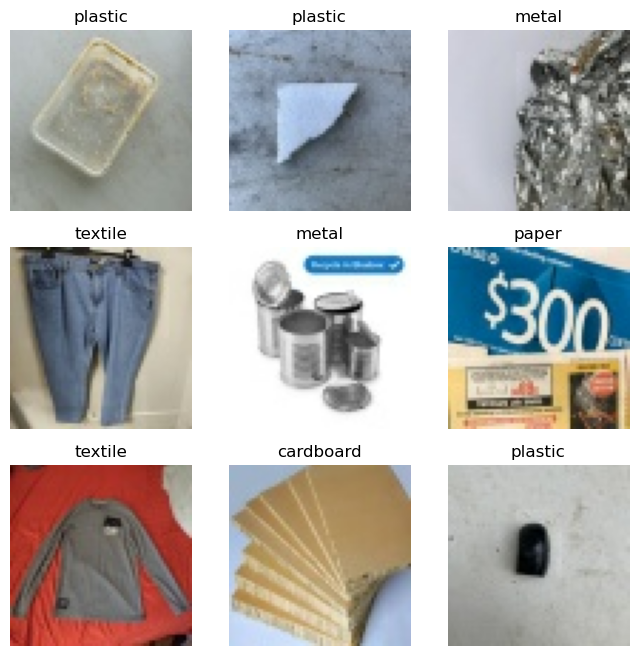

In [6]:
plt.figure(figsize=(8, 8))

for images, labels in dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [7]:
for images, labels in dataset.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)

Image batch shape: (32, 64, 64, 3)
Label batch shape: (32,)


### BUILDING MODEL MOVILENETV2

In [11]:
num_classes = len(class_names)

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(64, 64, 3),
    include_top=False,
    weights="imagenet",
    alpha=0.35
)

base_model.trainable = False

model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.build((None, 64, 64, 3))
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_1 (Rescaling)     (None, 64, 64, 3)         0         
                                                                 
 mobilenetv2_0.35_224 (Func  (None, 2, 2, 1280)        410208    
 tional)                                                         
                                                                 
 global_average_pooling2d_1  (None, 1280)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dropout_1 (Dropout)         (None, 1280)              0         
                                                                 
 dense_1 (Dense)             (None, 9)                 11529     
                                                                 
Total params: 421737 (1.61 MB)
Trainable params: 11529

In [12]:
history = model.fit(
    dataset,
    epochs=20
)

Epoch 1/20
263/263 [==============================] - 14s 40ms/step - loss: 1.8986 - accuracy: 0.4117
Epoch 2/20
263/263 [==============================] - 11s 41ms/step - loss: 1.3845 - accuracy: 0.5409
Epoch 3/20
263/263 [==============================] - 7s 27ms/step - loss: 1.2459 - accuracy: 0.5793
Epoch 4/20
263/263 [==============================] - 8s 29ms/step - loss: 1.1506 - accuracy: 0.6098
Epoch 5/20
263/263 [==============================] - 8s 30ms/step - loss: 1.1063 - accuracy: 0.6207
Epoch 6/20
263/263 [==============================] - 7s 26ms/step - loss: 1.0798 - accuracy: 0.6328
Epoch 7/20
263/263 [==============================] - 7s 26ms/step - loss: 1.0540 - accuracy: 0.6372
Epoch 8/20
263/263 [==============================] - 7s 26ms/step - loss: 1.0309 - accuracy: 0.6452
Epoch 9/20
263/263 [==============================] - 7s 25ms/step - loss: 1.0216 - accuracy: 0.6474
Epoch 10/20
263/263 [==============================] - 7s 27ms/step - loss: 1.0236 - accu

### train test and split 

In [13]:
DATASET_PATH = "../resized_dataset/"

IMG_SIZE = (64, 64)
BATCH_SIZE = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 8407 files belonging to 9 classes.
Using 6726 files for training.
Found 8407 files belonging to 9 classes.
Using 1681 files for validation.


In [15]:
class_names = train_ds.class_names
num_classes = len(class_names)

print(class_names)
print(num_classes)

['cardboard', 'e-waste', 'glass', 'metal', 'organic', 'paper', 'plastic', 'textile', 'trash']
9


In [16]:
val_size = int(0.5 * len(val_test_ds))

val_ds = val_test_ds.take(val_size)
test_ds = val_test_ds.skip(val_size)

In [17]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

In [20]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(64, 64, 3),
    include_top=False,
    weights="imagenet",
    alpha=0.5
)

base_model.trainable = False

model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.legacy.Adam(0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.build((None, 64, 64, 3))
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_3 (Rescaling)     (None, 64, 64, 3)         0         
                                                                 
 mobilenetv2_0.50_224 (Func  (None, 2, 2, 1280)        706224    
 tional)                                                         
                                                                 
 global_average_pooling2d_3  (None, 1280)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dropout_3 (Dropout)         (None, 1280)              0         
                                                                 
 dense_3 (Dense)             (None, 9)                 11529     
                                                                 
Total params: 717753 (2.74 MB)
Trainable params: 11529

In [21]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15
211/211 [==============================] - 12s 42ms/step - loss: 1.8696 - accuracy: 0.3732 - val_loss: 1.3822 - val_accuracy: 0.5156
Epoch 2/15
211/211 [==============================] - 8s 36ms/step - loss: 1.3774 - accuracy: 0.5296 - val_loss: 1.3008 - val_accuracy: 0.5541
Epoch 3/15
211/211 [==============================] - 7s 34ms/step - loss: 1.2374 - accuracy: 0.5767 - val_loss: 1.2347 - val_accuracy: 0.5757
Epoch 4/15
211/211 [==============================] - 10s 49ms/step - loss: 1.1492 - accuracy: 0.6012 - val_loss: 1.2231 - val_accuracy: 0.5841
Epoch 5/15
211/211 [==============================] - 9s 44ms/step - loss: 1.0960 - accuracy: 0.6158 - val_loss: 1.2017 - val_accuracy: 0.5889
Epoch 6/15
211/211 [==============================] - 9s 42ms/step - loss: 1.0349 - accuracy: 0.6445 - val_loss: 1.1843 - val_accuracy: 0.6070
Epoch 7/15
211/211 [==============================] - 8s 38ms/step - loss: 1.0087 - accuracy: 0.6456 - val_loss: 1.1872 - val_accuracy: 0.60

In [22]:
test_loss, test_acc = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

27/27 [==============================] - 3s 91ms/step - loss: 1.3211 - accuracy: 0.5689
Test Loss: 1.3211040496826172
Test Accuracy: 0.5689045786857605


In [23]:
model.save("../notebooks/models/waste_mobilenetv2_baseline.h5")
print(f"Model Saved")

/home/hrithik-dev/miniconda3/envs/waste-classification/lib/python3.10/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Model Saved


In [24]:
base_model.trainable = True

for layer in base_model.layers[:-60]:
    layer.trainable = False

In [25]:
model.compile(
    optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=5e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [26]:
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs= 40
)

Epoch 1/40
211/211 [==============================] - 35s 114ms/step - loss: 3.7984 - accuracy: 0.3846 - val_loss: 1.3531 - val_accuracy: 0.5625
Epoch 2/40
211/211 [==============================] - 14s 68ms/step - loss: 2.0151 - accuracy: 0.5326 - val_loss: 1.3129 - val_accuracy: 0.5853
Epoch 3/40
211/211 [==============================] - 17s 80ms/step - loss: 1.3399 - accuracy: 0.6195 - val_loss: 1.3138 - val_accuracy: 0.5793
Epoch 4/40
211/211 [==============================] - 16s 78ms/step - loss: 0.9877 - accuracy: 0.6970 - val_loss: 1.3041 - val_accuracy: 0.5853
Epoch 5/40
211/211 [==============================] - 22s 103ms/step - loss: 0.7350 - accuracy: 0.7547 - val_loss: 1.3390 - val_accuracy: 0.5805
Epoch 6/40
211/211 [==============================] - 19s 91ms/step - loss: 0.5768 - accuracy: 0.8073 - val_loss: 1.3547 - val_accuracy: 0.6034
Epoch 7/40
211/211 [==============================] - 15s 69ms/step - loss: 0.4606 - accuracy: 0.8452 - val_loss: 1.4304 - val_accurac

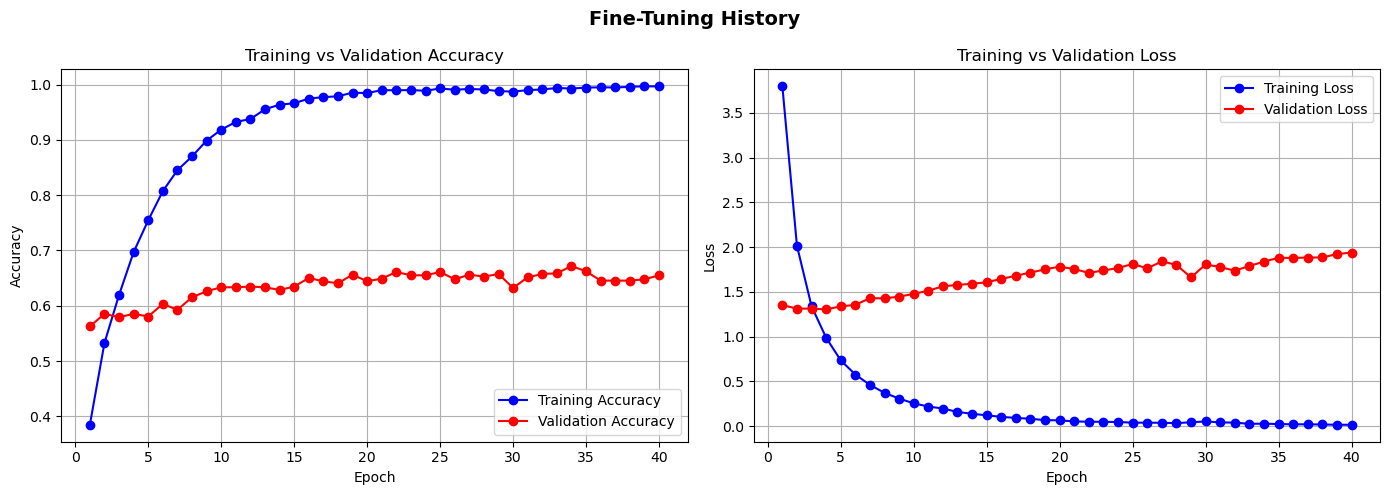

In [47]:
acc = history_fine.history['accuracy']
val_acc = history_fine.history['val_accuracy']
loss = history_fine.history['loss']
val_loss = history_fine.history['val_loss']

epochs = range(1, len(acc) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(epochs, acc, 'b-o', label='Training Accuracy')
ax1.plot(epochs, val_acc, 'r-o', label='Validation Accuracy')
ax1.set_title('Training vs Validation Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss
ax2.plot(epochs, loss, 'b-o', label='Training Loss')
ax2.plot(epochs, val_loss, 'r-o', label='Validation Loss')
ax2.set_title('Training vs Validation Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.suptitle('Fine-Tuning History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [27]:
val_loss, val_acc = model.evaluate(val_ds)
print("Validation Accuracy:", val_acc)
print("Validation Loss:", val_loss)

26/26 [==============================] - 1s 23ms/step - loss: 1.9399 - accuracy: 0.6550
Validation Accuracy: 0.6550480723381042
Validation Loss: 1.9399491548538208


In [28]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

27/27 [==============================] - 1s 22ms/step - loss: 2.1737 - accuracy: 0.6184
Test Accuracy: 0.6183745861053467
Test Loss: 2.1736717224121094


In [29]:
model.save("../notebooks/models/waste_mobilenetv2_finetuned.h5")

In [35]:
pred = np.argmax(model.predict(test_ds), axis=1)
true_labels = np.concatenate([y for x, y in test_ds], axis=0)

27/27 [==============================] - 1s 23ms/step


<Axes: >

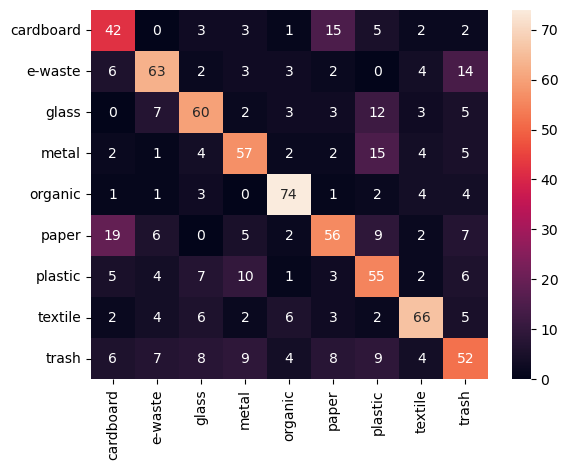

In [43]:
sns.heatmap(confusion_matrix(true_labels, pred), annot=True, xticklabels=class_names, yticklabels=class_names)

In [40]:
class_names

['cardboard',
 'e-waste',
 'glass',
 'metal',
 'organic',
 'paper',
 'plastic',
 'textile',
 'trash']

### Pruning 

In [48]:
import tensorflow_model_optimization as tfmot

prune_low_magnitude = tfmot.sparsity.keras.prune_low_magnitude

# manually scale dataset because we remove Rescaling layer
train_ds_scaled = train_ds.map(lambda x, y: (x / 255.0, y))
val_ds_scaled = val_ds.map(lambda x, y: (x / 255.0, y))
test_ds_scaled = test_ds.map(lambda x, y: (x / 255.0, y))

# remove Rescaling layer from original model
model_without_rescale = tf.keras.Sequential(model.layers[1:])

end_step = len(train_ds_scaled) * 5

pruning_params = {
    "pruning_schedule": tfmot.sparsity.keras.PolynomialDecay(
        initial_sparsity=0.20,
        final_sparsity=0.60,
        begin_step=0,
        end_step=end_step
    )
}

pruned_model = prune_low_magnitude(
    model_without_rescale,
    **pruning_params
)

pruned_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    tfmot.sparsity.keras.UpdatePruningStep()
]

history_pruned = pruned_model.fit(
    train_ds_scaled,
    validation_data=val_ds_scaled,
    epochs=5,
    callbacks=callbacks
)

Epoch 1/5


2026-04-26 14:45:10.951578: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [6726]
	 [[{{node Placeholder/_0}}]]
2026-04-26 14:45:10.951999: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [6726]
	 [[{{node Placeholder/_4}}]]


211/211 [==============================] - ETA: 0s - loss: 0.5402 - accuracy: 0.8488

2026-04-26 14:46:00.470591: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [1681]
	 [[{{node Placeholder/_4}}]]
2026-04-26 14:46:00.470919: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [1681]
	 [[{{node Placeholder/_0}}]]


211/211 [==============================] - 51s 76ms/step - loss: 0.5402 - accuracy: 0.8488 - val_loss: 3.8399 - val_accuracy: 0.2957
Epoch 2/5
211/211 [==============================] - 12s 57ms/step - loss: 2.1178 - accuracy: 0.5419 - val_loss: 6.7446 - val_accuracy: 0.1214
Epoch 3/5
211/211 [==============================] - 12s 58ms/step - loss: 3.4460 - accuracy: 0.3451 - val_loss: 8.2288 - val_accuracy: 0.1154
Epoch 4/5
211/211 [==============================] - 13s 63ms/step - loss: 4.0292 - accuracy: 0.2813 - val_loss: 6.7772 - val_accuracy: 0.1274
Epoch 5/5
211/211 [==============================] - 12s 56ms/step - loss: 3.7020 - accuracy: 0.2864 - val_loss: 5.6902 - val_accuracy: 0.1202


In [49]:
test_loss, test_acc = pruned_model.evaluate(test_ds_scaled)

print("Pruned Test Accuracy:", test_acc)
print("Pruned Test Loss:", test_loss)

 7/27 [======>.......................] - ETA: 0s - loss: 5.6339 - accuracy: 0.1161

2026-04-26 14:49:59.570122: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [1681]
	 [[{{node Placeholder/_4}}]]
2026-04-26 14:49:59.570529: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [1681]
	 [[{{node Placeholder/_4}}]]


27/27 [==============================] - 1s 24ms/step - loss: 5.6460 - accuracy: 0.1249
Pruned Test Accuracy: 0.12485276907682419
Pruned Test Loss: 5.645980358123779


In [50]:
model = tf.keras.models.load_model(
    "/mnt/d/waste-classification-system-II/notebooks/models/waste_mobilenetv2_finetuned.h5"
)

## Qunatization First 

In [51]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

with open("/mnt/d/waste-classification-system-II/notebooks/models/waste_mobilenetv2_quantized.tflite", "wb") as f:
    f.write(tflite_model)

print("TFLite quantized model saved")

2026-04-26 14:51:26.301023: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'inputs' with dtype float and shape [?,1280]
	 [[{{node inputs}}]]
2026-04-26 14:51:29.798801: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'inputs' with dtype float and shape [?,1280]
	 [[{{node inputs}}]]


INFO:tensorflow:Assets written to: /tmp/tmpdr0721wp/assets


INFO:tensorflow:Assets written to: /tmp/tmpdr0721wp/assets


TFLite quantized model saved


2026-04-26 14:51:48.904072: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
2026-04-26 14:51:48.904136: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-04-26 14:51:48.910909: I tensorflow/cc/saved_model/reader.cc:45] Reading SavedModel from: /tmp/tmpdr0721wp
2026-04-26 14:51:48.940843: I tensorflow/cc/saved_model/reader.cc:89] Reading meta graph with tags { serve }
2026-04-26 14:51:48.940919: I tensorflow/cc/saved_model/reader.cc:130] Reading SavedModel debug info (if present) from: /tmp/tmpdr0721wp
2026-04-26 14:51:49.052720: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:353] MLIR V1 optimization pass is not enabled
2026-04-26 14:51:49.082749: I tensorflow/cc/saved_model/loader.cc:231] Restoring SavedModel bundle.
2026-04-26 14:51:49.535235: I tensorflow/cc/saved_model/loader.cc:215] Running initialization op on SavedModel bundle at path: /tmp/tmpdr0721wp
2026-04

In [52]:
import os

size_mb = os.path.getsize(
    "/mnt/d/waste-classification-system-II/notebooks/models/waste_mobilenetv2_quantized.tflite"
) / (1024 * 1024)

print("Model size MB:", size_mb)

Model size MB: 0.8415603637695312


## Again training 

In [53]:
base_model1 = tf.keras.applications.MobileNetV2(
    input_shape=(64, 64, 3),
    include_top=False,
    weights="imagenet",
    alpha=0.35
)

In [54]:
base_model1.trainable = False

model1 = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255),
    base_model1,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(num_classes, activation="softmax")
])

model1.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model1.build((None, 64, 64, 3))
model1.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_3 (Rescaling)     (None, 64, 64, 3)         0         
                                                                 
 mobilenetv2_0.35_224 (Funct  (None, 2, 2, 1280)       410208    
 ional)                                                          
                                                                 
 global_average_pooling2d_3   (None, 1280)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dropout_3 (Dropout)         (None, 1280)              0         
                                                                 
 dense_3 (Dense)             (None, 9)                 11529     
                                                                 
Total params: 421,737
Trainable params: 11,529
Non-tra

In [56]:
model1.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [57]:
history = model1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15
211/211 [==============================] - 16s 48ms/step - loss: 1.9533 - accuracy: 0.4016 - val_loss: 1.3352 - val_accuracy: 0.5421
Epoch 2/15
211/211 [==============================] - 7s 33ms/step - loss: 1.4363 - accuracy: 0.5308 - val_loss: 1.2108 - val_accuracy: 0.5793
Epoch 3/15
211/211 [==============================] - 6s 29ms/step - loss: 1.2574 - accuracy: 0.5767 - val_loss: 1.1996 - val_accuracy: 0.5745
Epoch 4/15
211/211 [==============================] - 10s 47ms/step - loss: 1.1567 - accuracy: 0.6041 - val_loss: 1.1588 - val_accuracy: 0.6118
Epoch 5/15
211/211 [==============================] - 8s 36ms/step - loss: 1.1051 - accuracy: 0.6270 - val_loss: 1.1619 - val_accuracy: 0.5938
Epoch 6/15
211/211 [==============================] - 6s 28ms/step - loss: 1.0651 - accuracy: 0.6305 - val_loss: 1.1694 - val_accuracy: 0.5998
Epoch 7/15
211/211 [==============================] - 8s 37ms/step - loss: 1.0418 - accuracy: 0.6371 - val_loss: 1.1460 - val_accuracy: 0.61

#### Fine Tuning 

In [58]:
base_model1.trainable = True

for layer in base_model1.layers[:-40]:
    layer.trainable = False

In [59]:
model1.compile(
    optimizer=tf.keras.optimizers.Adam(5e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [61]:
history_fine = model1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30
)

Epoch 1/30
211/211 [==============================] - 9s 43ms/step - loss: 0.8026 - accuracy: 0.7147 - val_loss: 1.0912 - val_accuracy: 0.6575
Epoch 2/30
211/211 [==============================] - 8s 39ms/step - loss: 0.7869 - accuracy: 0.7282 - val_loss: 1.0772 - val_accuracy: 0.6659
Epoch 3/30
211/211 [==============================] - 10s 48ms/step - loss: 0.7505 - accuracy: 0.7379 - val_loss: 1.0821 - val_accuracy: 0.6623
Epoch 4/30
211/211 [==============================] - 9s 41ms/step - loss: 0.6916 - accuracy: 0.7492 - val_loss: 1.0557 - val_accuracy: 0.6755
Epoch 5/30
211/211 [==============================] - 11s 51ms/step - loss: 0.6950 - accuracy: 0.7541 - val_loss: 1.0437 - val_accuracy: 0.6695
Epoch 6/30
211/211 [==============================] - 12s 57ms/step - loss: 0.6531 - accuracy: 0.7728 - val_loss: 1.0418 - val_accuracy: 0.6719
Epoch 7/30
211/211 [==============================] - 8s 38ms/step - loss: 0.6458 - accuracy: 0.7652 - val_loss: 1.0354 - val_accuracy: 0.6

In [62]:
test_loss, test_acc = model1.evaluate(test_ds)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

27/27 [==============================] - 1s 25ms/step - loss: 1.1198 - accuracy: 0.6914
Test Accuracy: 0.6914016604423523
Test Loss: 1.1198041439056396


In [63]:
model1.save("/mnt/d/waste-classification-system-II/notebooks/models/waste_mobilenetv2_alpha035_finetuned.h5")

### INT_8 Quantization 

In [64]:
def representative_data_gen():
    for images, labels in train_ds.take(100):
        yield [tf.cast(images, tf.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(model1)

converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen

converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.uint8
converter.inference_output_type = tf.uint8

tflite_model = converter.convert()

path = "/mnt/d/waste-classification-system-II/notebooks/models/waste_mobilenetv2_alpha035_int8.tflite"

with open(path, "wb") as f:
    f.write(tflite_model)

print("INT8 TFLite model saved")

2026-04-26 15:31:13.406187: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'inputs' with dtype float and shape [?,1280]
	 [[{{node inputs}}]]
2026-04-26 15:31:22.195684: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'inputs' with dtype float and shape [?,1280]
	 [[{{node inputs}}]]


INFO:tensorflow:Assets written to: /tmp/tmpb530qnui/assets


INFO:tensorflow:Assets written to: /tmp/tmpb530qnui/assets
/home/krishna/miniconda3/envs/tf_gpu/lib/python3.10/site-packages/tensorflow/lite/python/convert.py:789: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn("Statistics for quantized inputs were expected, but not "
2026-04-26 15:31:39.746929: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
2026-04-26 15:31:39.746983: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-04-26 15:31:39.747694: I tensorflow/cc/saved_model/reader.cc:45] Reading SavedModel from: /tmp/tmpb530qnui
2026-04-26 15:31:39.778442: I tensorflow/cc/saved_model/reader.cc:89] Reading meta graph with tags { serve }
2026-04-26 15:31:39.778514: I tensorflow/cc/saved_model/reader.cc:130] Reading SavedModel debug info (if present) from: /tmp/tmpb530qnui
2026-04-26 15:31:39.931979: I tensorflow/cc/save

INT8 TFLite model saved


fully_quantize: 0, inference_type: 6, input_inference_type: UINT8, output_inference_type: UINT8


In [65]:
import os

size_kb = os.path.getsize(path) / 1024
print("Model size KB:", size_kb)

Model size KB: 621.1171875
